[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dandi/example-notebooks/blob/master/000718/CaiLab/zaki_2024/000718_demo.ipynb)

## Installing requirements

The cell below installs every Python package needed to run this notebook, at fully pinned versions, using [`uv`](https://github.com/astral-sh/uv) for fast resolution. In Colab the cell is collapsed by default — click the ▶ button to run it.

In [ ]:
#@title Installing requirements (click ▶ to run) { display-mode: "form" }
# Colab provides Python 3.13. We install with `uv --system` because Colab's
# kernel runs outside a virtualenv. All versions (direct + transitive) are
# pinned below so the notebook is reproducible regardless of resolver drift.
!pip install -q uv
!uv pip install --system \
    "acres==0.5.0" \
    "aiohappyeyeballs==2.7.1" \
    "aiohttp==3.14.3" \
    "aiosignal==1.4.0" \
    "annotated-types==0.8.0" \
    "arrow==1.4.0" \
    "attrs==26.1.0" \
    "bids-validator-deno==3.0.1" \
    "bidsschematools==1.2.7" \
    "blessed==1.48.0" \
    "certifi==2026.7.22" \
    "cffi==2.1.1" \
    "charset-normalizer==3.4.9" \
    "ci-info==0.4.0" \
    "click==8.4.2" \
    "click-didyoumean==0.3.1" \
    "contourpy==1.3.3" \
    "cryptography==50.0.0" \
    "cycler==0.12.1" \
    "dandi==0.77.0" \
    "dandischema==0.14.0" \
    "deno==2.9.5" \
    "dnspython==2.8.0" \
    "donfig==0.8.1.post1" \
    "email-validator==2.3.0" \
    "etelemetry==0.3.1" \
    "fasteners==0.20" \
    "fonttools==4.63.0" \
    "fqdn==1.5.1" \
    "frozenlist==1.8.0" \
    "fscacher==0.4.4" \
    "fsspec==2025.3.0" \
    "google-crc32c==1.8.0" \
    "h5py==3.16.0" \
    "hdmf==4.3.1" \
    "humanize==4.16.0" \
    "idna==3.18" \
    "interleave==0.3.0" \
    "isodate==0.7.2" \
    "isoduration==20.11.0" \
    "jaraco-classes==3.4.0" \
    "jaraco-context==6.1.2" \
    "jaraco-functools==4.6.0" \
    "jeepney==0.9.0" \
    "jinxed==2.1.0" \
    "joblib==1.5.3" \
    "jsonpointer==3.1.1" \
    "jsonschema==4.26.0" \
    "jsonschema-specifications==2025.9.1" \
    "keyring==25.7.0" \
    "keyrings-alt==5.0.2" \
    "kiwisolver==1.5.0" \
    "matplotlib==3.10.0" \
    "ml-dtypes==0.6.0" \
    "more-itertools==10.8.0" \
    "multidict==6.7.1" \
    "natsort==8.4.0" \
    "numcodecs==0.16.5" \
    "numpy==2.1.3" \
    "nwbinspector==0.7.2" \
    "packaging==26.3" \
    "pandas==2.2.3" \
    "pillow==11.3.0" \
    "platformdirs==4.11.3" \
    "propcache==0.5.2" \
    "pycparser==3.0" \
    "pycryptodomex==3.23.0" \
    "pydantic==2.13.4" \
    "pydantic-core==2.46.4" \
    "pydantic-settings==2.15.0" \
    "pynwb==3.1.3" \
    "pyout==0.8.1" \
    "pyparsing==3.3.2" \
    "python-dateutil==2.9.0.post0" \
    "python-dotenv==1.2.3" \
    "pytz==2025.2" \
    "pyyaml==6.0.3" \
    "referencing==0.37.0" \
    "remfile==0.1.14" \
    "requests==2.32.4" \
    "rfc3339-validator==0.1.4" \
    "rfc3987==1.3.8" \
    "rpds-py==2026.6.3" \
    "ruamel-yaml==0.19.1" \
    "secretstorage==3.5.0" \
    "semantic-version==2.10.0" \
    "six==1.17.0" \
    "tenacity==9.1.4" \
    "tensorstore==0.1.85" \
    "tqdm==4.67.3" \
    "typing-extensions==4.16.0" \
    "typing-inspection==0.4.4" \
    "tzdata==2026.3" \
    "uri-template==1.3.0" \
    "urllib3==2.5.0" \
    "wcwidth==0.8.2" \
    "webcolors==25.10.0" \
    "yarl==1.24.5" \
    "zarr==3.1.5" \
    "zarr-checksum==0.4.7"

> **⚠️ Restart runtime after install**
>
> The install may upgrade packages already loaded in the kernel. Go to **Runtime → Restart session**, then **Run all cells below** (skip this install cell on re-run).

# **Offline ensemble co-reactivation links memories across days**. 

This tutorial shows how to access the data related to [DANDI:000718](https://dandiarchive.org/dandiset/000718/draft) using `pynwb`. 

This dataset contains sessions with the 1-photon calcium imaging, calcium imaging segmentation, freezing behavior and behavioral video and other sessions with calcium imaging, calcium imaging segmentation, sleep behavior, EEG, EMG signals along with subject and session metadata.

Contents:

- [Streaming an NWB file](#stream-nwb)
- [Access Subject and Session metadata](#access-subject)
- [Access Raw Imaging](#access-raw-imaging)
- [Access Processed Imaging](#access-raw-imaging)
- [Access Freezing Behavior](#access-freezing)
- [Access EEG or Emg Traces](#access-eeg)
- [Access Sleep Classification](#access-sleep)
- [Access Week-long recordings and cross sessions cell registration](#access-week)

A schematic representation of the dataset:

![Alt text](assets/cai-conversion-ouput-dataset-structure.png)

A schematic representation NWB file structure for the conditioning sessions ("NeutralExposure", "FC", "Recall1", "Recall2", "Recall3"):

![Alt text](assets/cai-conversion-ouput-conditioning-session-nwb.png)

A schematic representation NWB file structure for the offline sessions:

![Alt text](assets/cai-conversion-ouput-offline-session-nwb.png)

A schematic representation NWB file structure for the week-long session:

![Alt text](assets/cai-conversion-ouput-week-session-nwb.png)


# Select the subject and session you want to load

In [1]:
dandiset_id = "000718"
subject_id = "Ca-EEG3-4"
session_id = "FC"

# Streaming an NWB file from DANDI <a id="stream-nwb"></a>

This section demonstrates how to access the files on the [DANDI Archive](https://dandiarchive.org) without downloading them. Based on the [Streaming NWB files](https://pynwb.readthedocs.io/en/stable/tutorials/advanced_io/streaming.html) tutorial from [PyNWB](https://pynwb.readthedocs.io/en/stable/#).

The `dandi.dandiapi.DandiAPIClient` can be used to get the S3 URL of the NWB file stored in the DANDI Archive.
We will use `remfile` for streaming the file. You can read more about `remfile` at [this tutorial section](https://pynwb.readthedocs.io/en/stable/tutorials/advanced_io/streaming.html#method-3-remfile).

In [2]:
from dandi.dandiapi import DandiAPIClient

nwbfile_path = f"sub-{subject_id}/sub-{subject_id}_ses-{session_id}_image+ophys.nwb"

dandiset_id = "000718"
with DandiAPIClient() as client:
    asset = client.get_dandiset(dandiset_id, 'draft').get_asset_by_path(nwbfile_path)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=False)

import h5py
import remfile
from pynwb import NWBHDF5IO

file = remfile.File(s3_url)
h5_file = h5py.File(file, "r")
io = NWBHDF5IO(file=h5_file, load_namespaces=True)

Importantly, the `session start time` is the reference time for all timestamps in the file. For instance, an event with a timestamp of 0 in the file means the event occurred exactly at the session start time.

The `session_start_time` is extracted from all_sessions.Session datajoint table.

In [3]:
nwbfile = io.read()
nwbfile

,start_time,stop_time,shock_amplitude
id,,,
0,120.0,122.0,0.25
1,180.0,182.0,0.25
2,240.0,242.0,0.25
,start_time,stop_time,timeseries
id,,,
0,79.239333,80.172667,"[(2377, 28, MotionSeries pynwb.base.TimeSeries at 0x1957617771856\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (8217,), type ""<f8"">\n description: ezTrack measures the motion of the animal by assessing the number of pixels of the behavioral video whose grayscale change exceeds a particular threshold from one frame to the next.\n offset: 0.0\n rate: 30.0\n resolution: -1.0\n starting_time: 0.006\n starting_time_unit: seconds\n unit: n.a\n)]"
1,143.639333,144.706000,"[(4309, 32, MotionSeries pynwb.base.TimeSeries at 0x1957617771856\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (8217,), type ""<f8"">\n description: ezTrack measures the motion of the animal by assessing the number of pixels of the behavioral video whose grayscale change exceeds a particular threshold from one frame to the next.\n offset: 0.0\n rate: 30.0\n resolution: -1.0\n starting_time: 0.006\n starting_time_unit: seconds\n unit: n.a\n)]"
2,147.406000,148.172667,"[(4422, 23, MotionSeries pynwb.base.TimeSeries at 0x1957617771856\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (8217,), type ""<f8"">\n description: ezTrack measures the motion of the animal by assessing the number of pixels of the behavioral video whose grayscale change exceeds a particular threshold from one frame to the next.\n offset: 0.0\n rate: 30.0\n resolution: -1.0\n starting_time: 0.006\n starting_time_unit: seconds\n unit: n.a\n)]"
3,151.706000,152.206000,"[(4551, 15, MotionSeries pynwb.base.TimeSeries at 0x1957617771856\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (8217,), type ""<f8"">\n description: ezTrack measures the motion of the animal by assessing the number of pixels of the behavioral video whose grayscale change exceeds a particular threshold from one frame to the next.\n offset: 0.0\n rate: 30.0\n resolution: -1.0\n starting_time: 0.006\n starting_time_unit: seconds\n unit: n.a\n)]"


In [4]:
nwbfile.session_start_time

datetime.datetime(2022, 9, 19, 9, 18, 41, 1000, tzinfo=tzoffset(None, -14400))

In [5]:
nwbfile.experiment_description

'Simultaneous calcium imaging with Miniscopes and EEG/EMG experiment during retrospective memory-linking behavioral paradigm, to test whether ensemble co-reactivation is sleep-state specific. Mice were exposed to the neutral context for 10 min to explore. During aversive encoding, after a baseline period of 2 min, mice received three 2 s foot shocks of either amplitude 0.25 mA (low-shock) or 1.5 mA (high-shock), with an intershock interval of 1 min. Then, 30 s after the final shock, the mice were removed and returned to the vivarium. On the next 3 days, the mice were tested in the previously experienced aversive and neutral contexts, as well as a completely novel context that they had not been exposed to previously, for 5 min each. The features of the neutral and novel contexts were counter-balanced and were made up of different olfactory, auditory, lighting and tactile cues. The aversive context was always the same with distinct cues from the neutral and novel contexts. In the low- ve

In [6]:
nwbfile.session_description

'Fear Conditioning session: after a baseline period of 2 min, mouse received three 2s foot shocks of 0.25, with an intershock interval of 1 min. Then, 30 s after the final shock, the mice were removed and returned to the vivarium. Context: overhead external light, external fan at medium level, box fan on, even grid floor, acetic acid 1pct scent'

# Access subject <a name="access-subject"></a>

This section demonstrates how to access the [Subject](https://pynwb.readthedocs.io/en/stable/pynwb.file.html#pynwb.file.Subject) field in an NWB file.

The [Subject](https://pynwb.readthedocs.io/en/stable/pynwb.file.html#pynwb.file.Subject) field can be accessed as `nwbfile.subject`.


In [7]:
nwbfile.subject

subject pynwb.file.Subject at 0x1957617826576
Fields:
  age: P12W/P18W
  age__reference: birth
  description: Adult C57BL/6J wild-type mice from Jackson Laboratories were used. Mice ordered from Jackson arrived group-housed in cages of 4 mice/cage and were singly housed for the experiment. Mice were ordered to arrive at 8-9 weeks of age and underwent behavioral testing about 4-6 weeks after the arrival date. All experimental procedures were approved by the Icahn School of Medicine at Mount Sinai's IACUC.
  genotype: wild-type
  sex: M
  species: Mus musculus
  strain: C57BL/6J
  subject_id: Ca_EEG3-4

# Access OnePhoton Imaging

This section demonstraces how to access the raw One Photon imaging data.

`NWB` organizes data into different groups depending on the type of data. Groups can be thought of as folders within the file. Here are some of the groups within an NWBFile and the types of data they are intended to store:

- `acquisition`: raw, acquired data that should never change
- `processing`: processed data, typically the results of preprocessing algorithms and could change

## Raw OnePhoton Imaging <a name="access-imaging"></a>

The raw OnePhoton imaging data is stored in `pynwb.ophys.OnePhotonSeries` objects (for each channel and plane separately) which is added to `nwbfile.acquisition`.

The data in [OnePhotonSeries](https://pynwb.readthedocs.io/en/stable/pynwb.ophys.html#pynwb.ophys.OnePhotonSeries) is stored as a three dimensional array: the first dimension is time (frame), the second and third dimensions represent x and y (width by height). 

In [8]:
photon_series_name = "OnePhotonSeries"
photon_series = nwbfile.acquisition[photon_series_name]
photon_series

OnePhotonSeries pynwb.ophys.OnePhotonSeries at 0x1957618143632
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (8161, 608, 608), type "|u1">
  description: Imaging data from Miniscope.
  dimension: <HDF5 dataset "dimension": shape (2,), type "<i4">
  imaging_plane: ImagingPlane pynwb.ophys.ImagingPlane at 0x1958213157200
Fields:
  conversion: 1.0
  description: Imaging plane for Miniscope imaging data.
  device: Microscope abc.Miniscope at 0x1957617778064
Fields:
  ROI: <HDF5 dataset "ROI": shape (2,), type "<i4">
  compression: FFV1
  description: The Miniscope is the head-mounted miniature microscope part of the UCLA Miniscope imaging platform.
  deviceType: Miniscope_V4_BNO
  frameRate: 30FPS
  framesPerFile: 1000
  gain: 3.5
  led0: 1

  excitation_lambda: 496.0
  grid_spacing_unit: meters
  imaging_rate: 30.0
  indicator: GCaMP6f
  location: CA1
  optical_channel: (
    GreenChannel <class 'pynwb.ophys.OpticalChannel'>,
    OpticalChannel <class 'pynwb.ophys.OpticalChannel'>
  )
  origin_coords_unit: meters
  unit: meters

  interval: 1
  offset: 0.0
  resolution: -1.0
  timestamps: <HDF5 dataset "timestamps": shape (8161,), type "<f8">
  timestamps_unit: seconds
  unit: n.a.

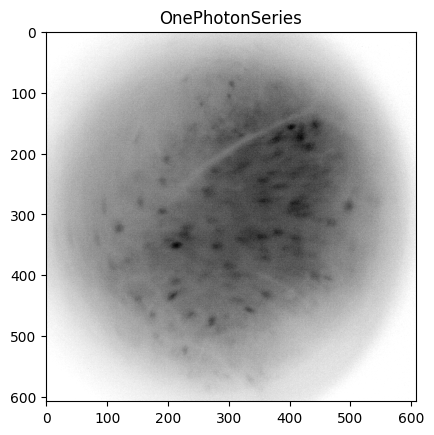

In [9]:
# Visualize the imaging data.
from matplotlib import pyplot as plt
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True, sharey=True)
ax.imshow(photon_series.data[70], cmap="binary")
ax.set_title(photon_series_name)
plt.show()


In [10]:
photon_series.timestamps[:100]

array([0.   , 0.034, 0.068, 0.1  , 0.133, 0.168, 0.201, 0.234, 0.268,
       0.302, 0.335, 0.369, 0.403, 0.435, 0.469, 0.504, 0.537, 0.571,
       0.605, 0.638, 0.671, 0.705, 0.738, 0.771, 0.806, 0.839, 0.873,
       0.907, 0.94 , 0.974, 1.007, 1.041, 1.074, 1.107, 1.142, 1.175,
       1.208, 1.243, 1.275, 1.308, 1.343, 1.376, 1.41 , 1.444, 1.476,
       1.511, 1.545, 1.578, 1.612, 1.645, 1.678, 1.712, 1.745, 1.778,
       1.813, 1.846, 1.879, 1.915, 1.947, 1.98 , 2.014, 2.048, 2.08 ,
       2.115, 2.148, 2.182, 2.215, 2.25 , 2.283, 2.316, 2.351, 2.384,
       2.417, 2.451, 2.484, 2.517, 2.552, 2.585, 2.618, 2.653, 2.685,
       2.718, 2.753, 2.786, 2.819, 2.853, 2.887, 2.921, 2.954, 2.988,
       3.021, 3.055, 3.089, 3.122, 3.155, 3.19 , 3.223, 3.257, 3.29 ,
       3.323])

In [11]:
photon_series.dimension[:]

array([608, 608], dtype=int32)

Imaging metadata include information on the **device** used to acquire the image and the **optical channel** specs contained in the imaging plane object

In [12]:
nwbfile.imaging_planes["ImagingPlane"]

ImagingPlane pynwb.ophys.ImagingPlane at 0x1958213157200
Fields:
  conversion: 1.0
  description: Imaging plane for Miniscope imaging data.
  device: Microscope abc.Miniscope at 0x1957617778064
Fields:
  ROI: <HDF5 dataset "ROI": shape (2,), type "<i4">
  compression: FFV1
  description: The Miniscope is the head-mounted miniature microscope part of the UCLA Miniscope imaging platform.
  deviceType: Miniscope_V4_BNO
  frameRate: 30FPS
  framesPerFile: 1000
  gain: 3.5
  led0: 1

  excitation_lambda: 496.0
  grid_spacing_unit: meters
  imaging_rate: 30.0
  indicator: GCaMP6f
  location: CA1
  optical_channel: (
    GreenChannel <class 'pynwb.ophys.OpticalChannel'>,
    OpticalChannel <class 'pynwb.ophys.OpticalChannel'>
  )
  origin_coords_unit: meters
  unit: meters

In [13]:
nwbfile.devices["Microscope"]

Microscope abc.Miniscope at 0x1957617778064
Fields:
  ROI: <HDF5 dataset "ROI": shape (2,), type "<i4">
  compression: FFV1
  description: The Miniscope is the head-mounted miniature microscope part of the UCLA Miniscope imaging platform.
  deviceType: Miniscope_V4_BNO
  frameRate: 30FPS
  framesPerFile: 1000
  gain: 3.5
  led0: 1

## Accessing the segmentation data

The segmentation output for the One Photon Imaging data is stored in `nwbfile.processing["ophys"]`. 

In NWB, the [PlaneSegmentation](https://pynwb.readthedocs.io/en/stable/pynwb.ophys.html#pynwb.ophys.PlaneSegmentation) class stores the detected regions of interest in the [OnePhotonSeries](https://pynwb.readthedocs.io/en/stable/pynwb.ophys.html#pynwb.ophys.OnePhotonSeries) data. The [ImageSegmentation](https://pynwb.readthedocs.io/en/stable/pynwb.ophys.html#pynwb.ophys.ImageSegmentation) can contain multiple `PlaneSegmentation` tables, so that we can store results of different segmentation algorithms or different segmentation classes.

We can access the plane segmentation for the [OnePhotonSeries](https://pynwb.readthedocs.io/en/stable/pynwb.ophys.html#pynwb.ophys.OnePhotonSeries) data as 
`nwbfile.processing["ophys"]["ImageSegmentation"]["PlaneSegmentationChannel_number_Plane_number_"]`.

In [14]:
nwbfile.processing["ophys"]

ophys pynwb.base.ProcessingModule at 0x1957598159248
Fields:
  data_interfaces: {
    Fluorescence <class 'pynwb.ophys.Fluorescence'>,
    ImageSegmentation <class 'pynwb.ophys.ImageSegmentation'>,
    SegmentationImages <class 'pynwb.base.Images'>
  }
  description: No description.

### The SegmentationImages data interface
 SegmentationImages data interface contains summary images such as the Maximum Projection Image

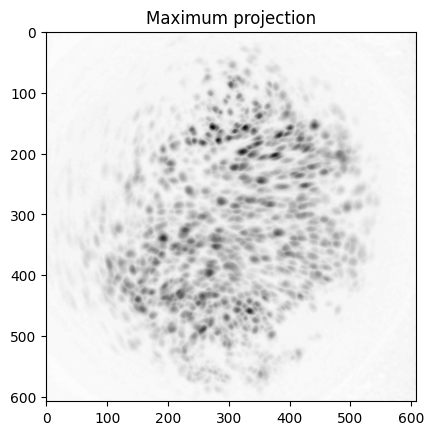

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True, sharey=True)
max_projection_image = nwbfile.processing["ophys"]["SegmentationImages"].images["maximum_projection"]
ax.imshow(max_projection_image.data[:], cmap="binary")
ax.set_title("Maximum projection")
plt.show()

### The ImageSegmentation data interface
 ImageSegmentation data interface contains the spatial data of the segmentation output.
 The PlaneSegmentation stores masks of an image that represent different regions of interest (ROIs). All segmentation for a given imaging plane is stored together, with storage for multiple imaging planes (masks) supported. Each ROI is stored in its own subgroup, with the ROI group containing both a 2D mask and a list of pixels that make up this mask. 

In [16]:
plane_segmentation_names = list(nwbfile.processing["ophys"]["ImageSegmentation"].plane_segmentations.keys())
_ = [print(name) for name in nwbfile.processing["ophys"]["ImageSegmentation"].plane_segmentations.keys()]

BackgroundPlaneSegmentation
PlaneSegmentation


In [17]:
plane_seg_name = "PlaneSegmentation"
plane_segmentation = nwbfile.processing["ophys"]["ImageSegmentation"].plane_segmentations[plane_seg_name]
plane_segmentation.to_dataframe()

,image_mask,ROICentroids
id,,
0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[341, 39]"
1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[444, 43]"
2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[356, 62]"
3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[405, 62]"
4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[380, 64]"
...,...,...
778,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[315, 530]"
779,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[327, 529]"
780,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[277, 530]"


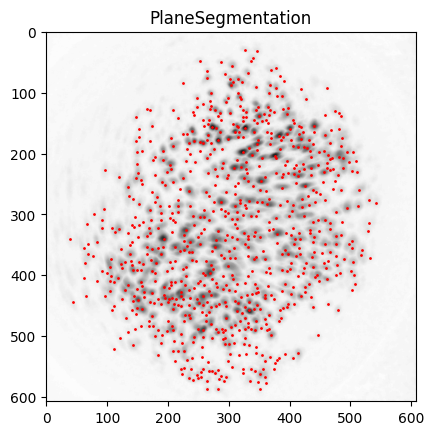

In [18]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True, sharey=True)   
ax.imshow(max_projection_image.data[:], cmap="binary")
for roi_centroid in plane_segmentation["ROICentroids"]:
    ax.scatter(roi_centroid[1], roi_centroid[0],c="red", s=1)
ax.set_title(plane_seg_name)
plt.show()

## The Fluorescence data interface
The Fluorescence data interface stores the fluorescence information about a region of interest (ROI): the ROI response series. 
Each ROI response series stores ROI responses over an imaging plane. Each column in data should correspond to the signal from one ROI.

In [19]:
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

roi_response_series_names = [name for name in nwbfile.processing["ophys"]["Fluorescence"].roi_response_series.keys()]
roi_response_series_names

['Baseline', 'Deconvolved', 'Denoised', 'neuropil']

In [20]:
roi_response_series = nwbfile.processing["ophys"]["Fluorescence"]["Denoised"]
roi_response_series

Denoised pynwb.ophys.RoiResponseSeries at 0x1957617764880
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (4076, 783), type "<f8">
  description: description of denoised traces
  interval: 1
  offset: 0.0
  resolution: -1.0
  rois: rois <class 'hdmf.common.table.DynamicTableRegion'>
  timestamps: <HDF5 dataset "timestamps": shape (4076,), type "<f8">
  timestamps_unit: seconds
  unit: n.a.

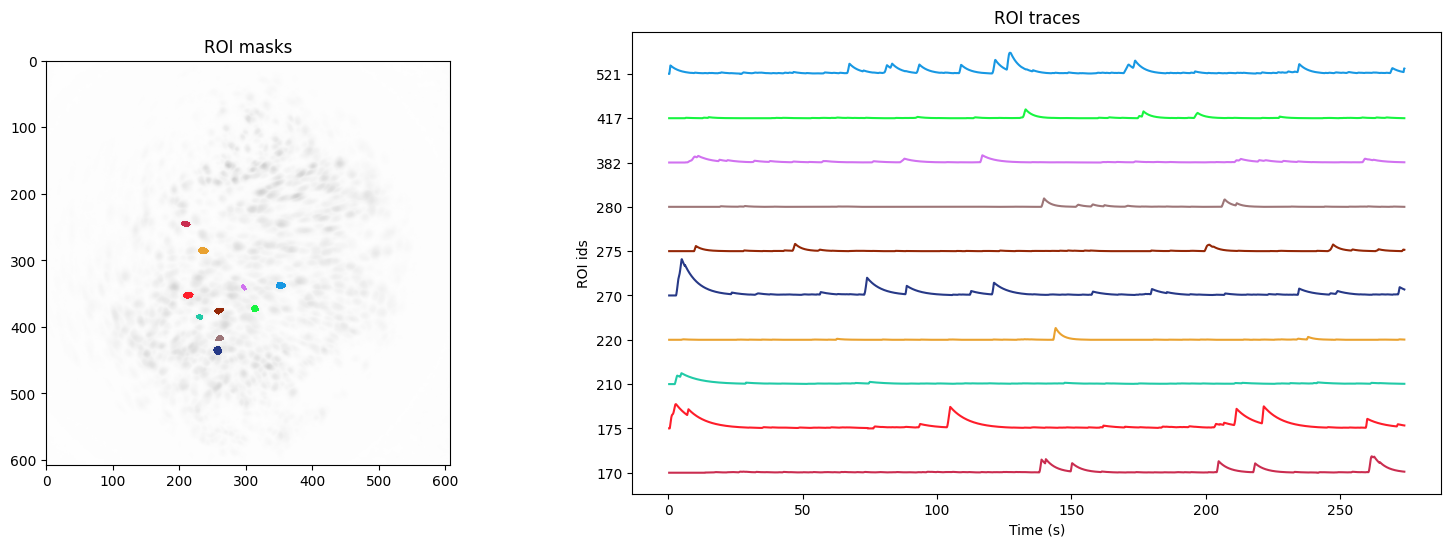

In [21]:
import random
from matplotlib.colors import ListedColormap
import numpy as np
roi_ids = [170, 175, 210, 220, 270, 275, 280, 382, 417, 521]
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 2], wspace=0.3)  
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 0])

ax2.imshow(max_projection_image.data[:], cmap="binary", alpha=0.2)

timestamps = roi_response_series.timestamps[:]
for n, roi_id in enumerate(roi_ids):
    random_color = [random.random() for _ in range(3)] + [1]
    custom_cmap = ListedColormap([[0, 0, 0, 0], random_color])
    
    ax1.plot(timestamps, roi_response_series.data[:,roi_id] + n*np.max(roi_response_series.data[:,:]), color=random_color)

    image_mask = plane_segmentation.image_mask[roi_id]

    ax2.imshow(image_mask, cmap=custom_cmap)

ax1.set_yticks([n*np.max(roi_response_series.data[:,:]) for n in range(len(roi_ids))])
ax1.set_yticklabels(roi_ids)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("ROI ids")
ax1.set_title("ROI traces")

ax2.set_title("ROI masks")

plt.show()

# Access Freezing Behavior <a name="access-freezing"></a>
#### **Only for conditioning session** "NeutralExposure", "FC", "Recall1", "Recall2", "Recall3"
This section demonstrates how to access the freeze analysis output and metadata.


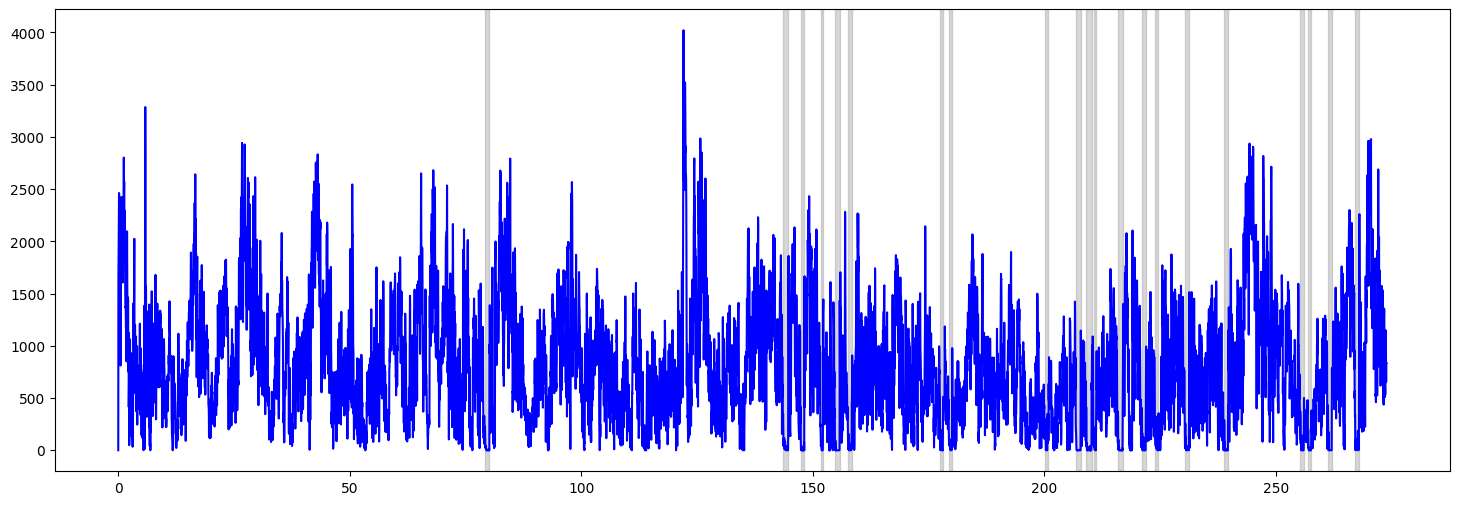

In [22]:
import numpy as np
motion_series = nwbfile.processing["behavior"]["MotionSeries"].data[:]
rate = nwbfile.processing["behavior"]["MotionSeries"].rate
starting_time = nwbfile.processing["behavior"]["MotionSeries"].starting_time
time = np.linspace(starting_time, motion_series.shape[0] / rate, motion_series.shape[0])
start_times = nwbfile.processing["behavior"]["FreezingIntervals"].start_time[:]
stop_times = nwbfile.processing["behavior"]["FreezingIntervals"].stop_time[:]
import matplotlib.pyplot as plt

# Plotting
fig, ax = plt.subplots(figsize=(18, 6))
# Overlay grey boxes for each interval
for start, stop in zip(start_times, stop_times):
    if start > motion_series.shape[0] / rate:
        break
    ax.axvspan(start, stop, color="grey", alpha=0.3)
# Plot the time series
ax.plot(time, motion_series, color="blue", label="Motion Series")
plt.show()

# Access Shock Stimulus table <a name="access-shock"></a>
#### **Only for fear conditioning session** "FC"
This section demonstrates how to access the shock stimulus table.

In [23]:
shock_stimulus = nwbfile.stimulus["ShockStimuli"]
shock_stimulus.description

'During aversive encoding, after a baseline period of 2 min, mice received three 2 s foot shocks of either amplitude 0.25 mA (low-shock) or 1.5 mA (high-shock), with an intershock interval of 1 min. All testing was done in Med Associates chambers. '

In [24]:
shock_stimulus.to_dataframe()

,start_time,stop_time,shock_amplitude
id,,,
0,120.0,122.0,0.25
1,180.0,182.0,0.25
2,240.0,242.0,0.25


# Access EEG or EMG Signals <a name="access-eeg"></a>
#### **Only for offline session** "OfflineDay1Session1", "OfflineDay1Session2", ..., "OfflineDay2Session1", ...

In [25]:
subject_id = "Ca-EEG3-4"
session_id = "OfflineDay1Session1"

In [26]:
from dandi.dandiapi import DandiAPIClient

nwbfile_path = f"sub-{subject_id}/sub-{subject_id}_ses-{session_id}_ophys.nwb"

dandiset_id = "000718"
with DandiAPIClient() as client:
    asset = client.get_dandiset(dandiset_id, 'draft').get_asset_by_path(nwbfile_path)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=False)

import h5py
import remfile
from pynwb import NWBHDF5IO

file = remfile.File(s3_url)
h5_file = h5py.File(file, "r")
io = NWBHDF5IO(file=h5_file, load_namespaces=True)
nwbfile = io.read()
nwbfile.session_description

'After Neutral Exposure and Fear Conditioning sessions, mice were taken out of the testing chambers and immediately placed in their homecage (scope was not removed).The homecage was placed in a dark grey storage bin with a webcam on top of the bin, taped to a wooden plank, looking down into the homecage. Mouse behavior and calcium were recorded for an hour.'

This section demonstrates how to access the data recorded with the HD-X02 wireless telemetry probe.

### EEG Signal

In [27]:
eeg_signal = nwbfile.acquisition["EEGSignal"]
eeg_signal

EEGSignal pynwb.base.TimeSeries at 0x1957635812880
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (300064,), type "<f4">
  description: EEG signal recorder with HD-X02 wireless telemetry probe
  offset: 0.0
  rate: 500.0
  resolution: -1.0
  starting_time: 0.0
  starting_time_unit: seconds
  unit: volts

In this case since the signal has regular timestamps, the starting time and rate are saved instead of timestamps. To retrieve the timestamps, we simply use the get_timestamps() function

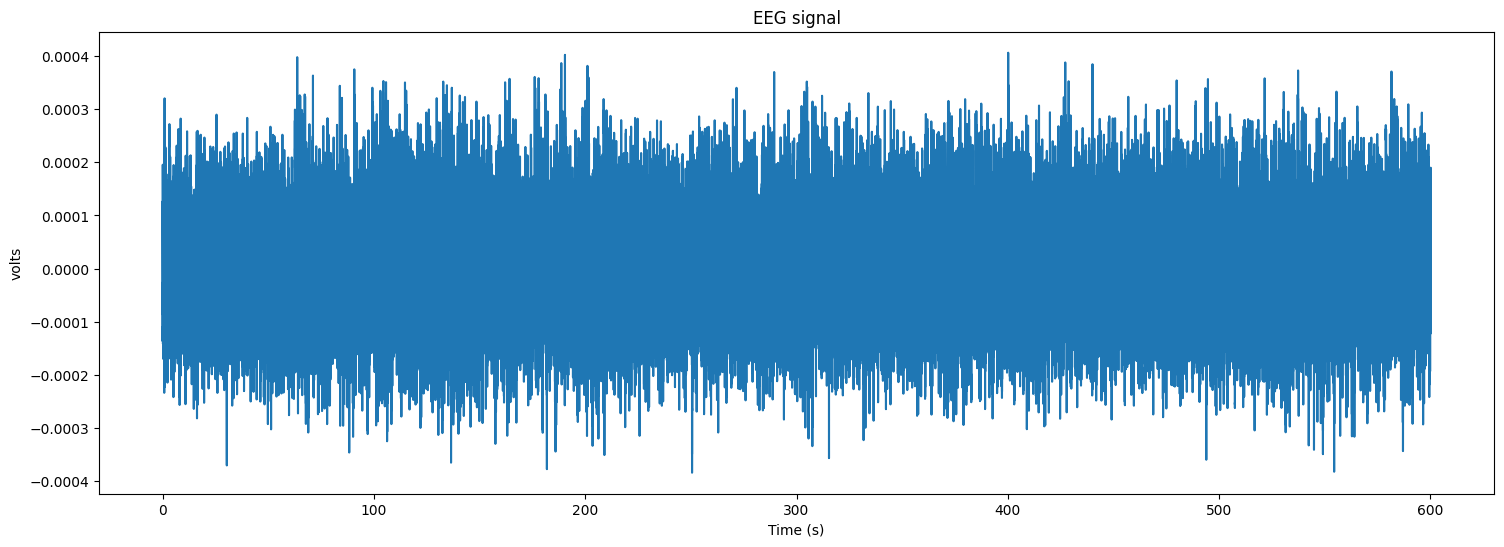

In [28]:
timestamps = eeg_signal.get_timestamps()
fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(timestamps, eeg_signal.data[:])
ax.set_title("EEG signal")
ax.set_xlabel("Time (s)")
ax.set_ylabel(eeg_signal.unit)
plt.show()

### EMG Signal

In [29]:
emg_signal = nwbfile.acquisition["EMGSignal"]
emg_signal

EMGSignal pynwb.base.TimeSeries at 0x1957627113040
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (300064,), type "<f4">
  description: EMG signal recorder with HD-X02 wireless telemetry probe
  offset: 0.0
  rate: 500.0
  resolution: -1.0
  starting_time: 0.0
  starting_time_unit: seconds
  unit: volts

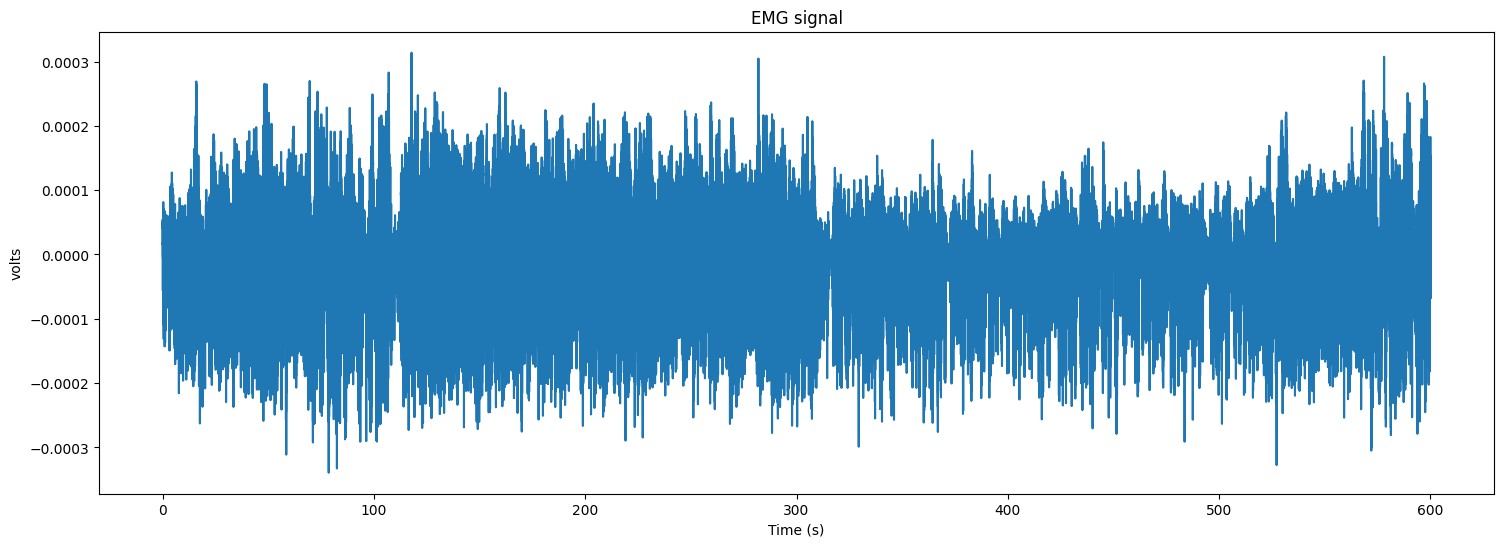

In [30]:
timestamps = emg_signal.get_timestamps()
fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(timestamps, emg_signal.data[:])
ax.set_title("EMG signal")
ax.set_xlabel("Time (s)")
ax.set_ylabel(emg_signal.unit)
plt.show()

### Temperature Signal

In [31]:
temperature_signal = nwbfile.acquisition["TemperatureSignal"]
temperature_signal

TemperatureSignal pynwb.base.TimeSeries at 0x1957639237520
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (300064,), type "<f4">
  description: Temperature signal recorder with HD-X02 wireless telemetry probe
  offset: 0.0
  rate: 500.0
  resolution: -1.0
  starting_time: 0.0
  starting_time_unit: seconds
  unit: celsius

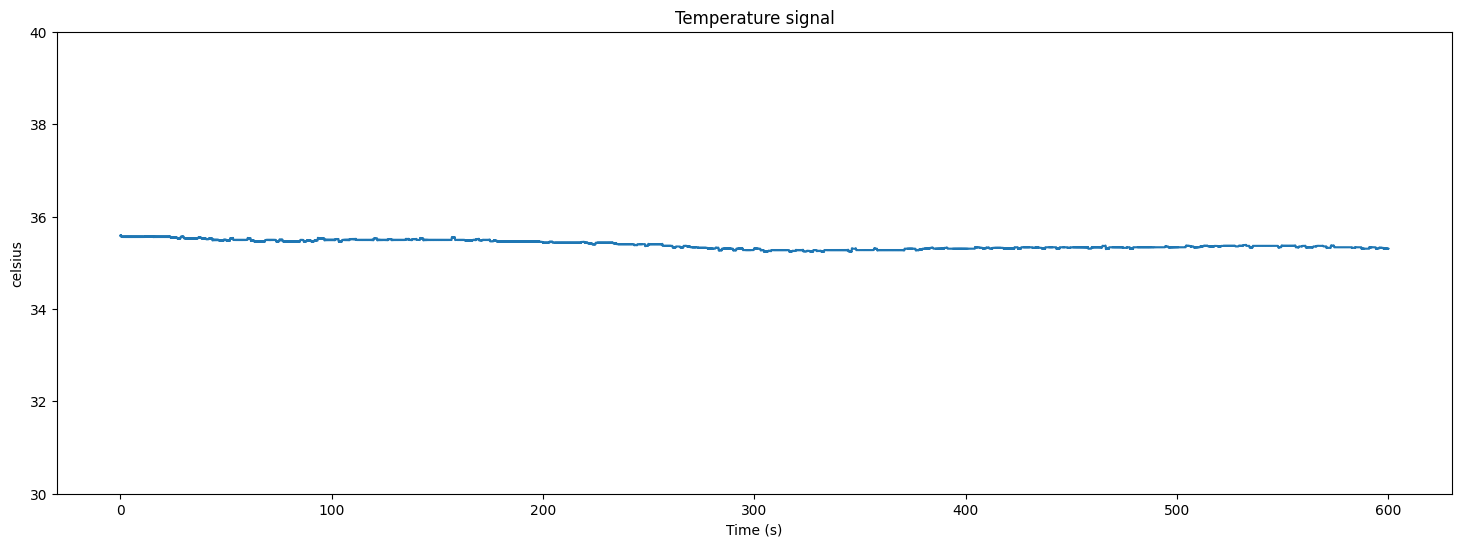

In [32]:
timestamps = temperature_signal.get_timestamps()
fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(timestamps, temperature_signal.data[:])
ax.set_title("Temperature signal")
ax.set_xlabel("Time (s)")
ax.set_ylabel(temperature_signal.unit)
ax.set_ylim(30, 40)
plt.show()

### Activity Signal

In [33]:
activity_signal = nwbfile.acquisition["ActivitySignal"]
activity_signal

ActivitySignal pynwb.base.TimeSeries at 0x1957766652496
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (300064,), type "<f4">
  description: Activity signal recorder with HD-X02 wireless telemetry probe. It refers to the motion of the probe relative to the receiver and it can be used as a proxy for locomotion.
  offset: 0.0
  rate: 500.0
  resolution: -1.0
  starting_time: 0.0
  starting_time_unit: seconds
  unit: n.a.

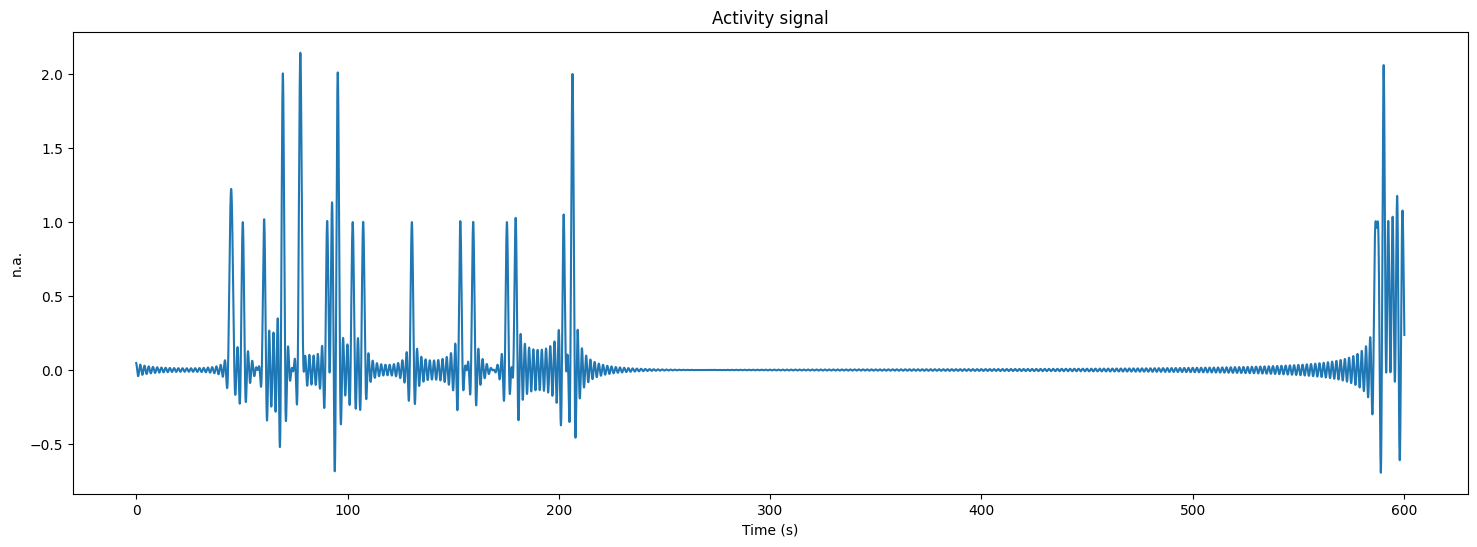

In [34]:
timestamps = activity_signal.get_timestamps()
fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(timestamps, activity_signal.data[:])
ax.set_title("Activity signal")
ax.set_xlabel("Time (s)")
ax.set_ylabel(activity_signal.unit)
plt.show()

# Access Sleep Classification <a name="access-sleep"></a>

This section demonstrates how to access the sleep classification data.

In [35]:
sleep_intervals = nwbfile.processing["sleep"]["SleepIntervals"].to_dataframe()
sleep_intervals


,start_time,stop_time,sleep_state
id,,,
0,0.000000,42.800000,quiet wake
1,42.866667,60.800000,wake
2,60.866667,66.733333,quiet wake
3,66.800000,78.800000,wake
4,78.866667,84.733333,quiet wake
5,84.800000,108.733333,wake
6,108.800000,126.800000,quiet wake
7,126.866667,132.733333,wake
8,132.800000,150.733333,quiet wake


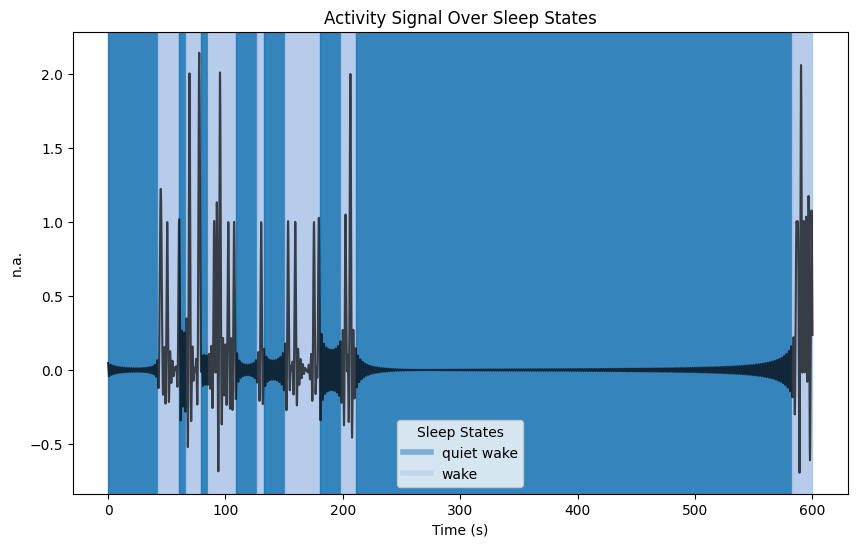

In [36]:
import matplotlib.pyplot as plt

unique_states = sleep_intervals["sleep_state"].unique()
colors = plt.cm.tab20.colors  # Use a color map with enough colors
color_mapping = {state: colors[i % len(colors)] for i, state in enumerate(unique_states)}

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Overlay boxes for each interval with dynamically assigned colors
for start, stop, state in zip(sleep_intervals["start_time"], sleep_intervals["stop_time"], sleep_intervals["sleep_state"]):
    ax.axvspan(start, stop, color=color_mapping[state], alpha=0.9, label=state)
    
ax.plot(activity_signal.get_timestamps(), activity_signal.data[:], color = "black", alpha=0.7)

ax.set_title("Activity Signal Over Sleep States")
ax.set_xlabel("Time (s)")
ax.set_ylabel(activity_signal.unit)

# Create a legend with unique sleep states
handles = [plt.Line2D([0], [0], color=color_mapping[state], lw=4, alpha=0.5) for state in unique_states]
ax.legend(handles, unique_states, title="Sleep States")

# Access Week-long recordings and cross sessions cell registration  <a name="access-week"></a>


In [37]:
subject_id = "Ca-EEG2-1"
session_id = "Week"

In [38]:
from dandi.dandiapi import DandiAPIClient

nwbfile_path = f"sub-{subject_id}/sub-{subject_id}_ses-{session_id}.nwb"

dandiset_id = "000718"
with DandiAPIClient() as client:
    asset = client.get_dandiset(dandiset_id, 'draft').get_asset_by_path(nwbfile_path)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=False)

import h5py
import remfile
from pynwb import NWBHDF5IO

file = remfile.File(s3_url)
h5_file = h5py.File(file, "r")
io = NWBHDF5IO(file=h5_file, load_namespaces=True)
nwbfile = io.read()
nwbfile

,Ca_EEG2-1_FC,Ca_EEG2-1_NeutralExposure,Ca_EEG2-1_OfflineDay2Session10,Ca_EEG2-1_Recall1
id,,,,
0,0,2,3,-9999
1,1,4,4,-9999
2,-9999,-9999,5,-9999
3,3,-9999,-9999,-9999
,Ca_EEG2-1_FC,Ca_EEG2-1_NeutralExposure,Ca_EEG2-1_OfflineDay2Session11,Ca_EEG2-1_Recall1
id,,,,
0,0,2,-9999,-9999
1,-9999,4,3,-9999
2,2,-9999,-9999,-9999


In [39]:
nwbfile.session_description

''

In [40]:
from datetime import timedelta

eeg_signal = nwbfile.acquisition["EEGSignal"]
n_samples = eeg_signal.data.shape[0]

# EEGSignal has a fixed sampling rate rather than stored timestamps, so the
# session length is arithmetic. get_timestamps() would build a
# 400-million-element array (several GB) just to read its last value.
# (pynwb >= 4 also offers eeg_signal.get_starting_time() and
# eeg_signal.get_duration() for this.)
duration_s = eeg_signal.starting_time + (n_samples - 1) / eeg_signal.rate

week_session_start = nwbfile.session_start_time
week_session_end = week_session_start + timedelta(seconds=duration_s)
week_session_start = week_session_start.strftime("%Y-%m-%d %H:%M:%S %Z")
week_session_end = week_session_end.strftime("%Y-%m-%d %H:%M:%S %Z")
print(f"Session started:\t{week_session_start} \nSession ended:\t\t{week_session_end}")

Session started:	2021-10-08 07:00:00 UTC 
Session ended:		2021-10-17 15:39:49 UTC


## EEG recording

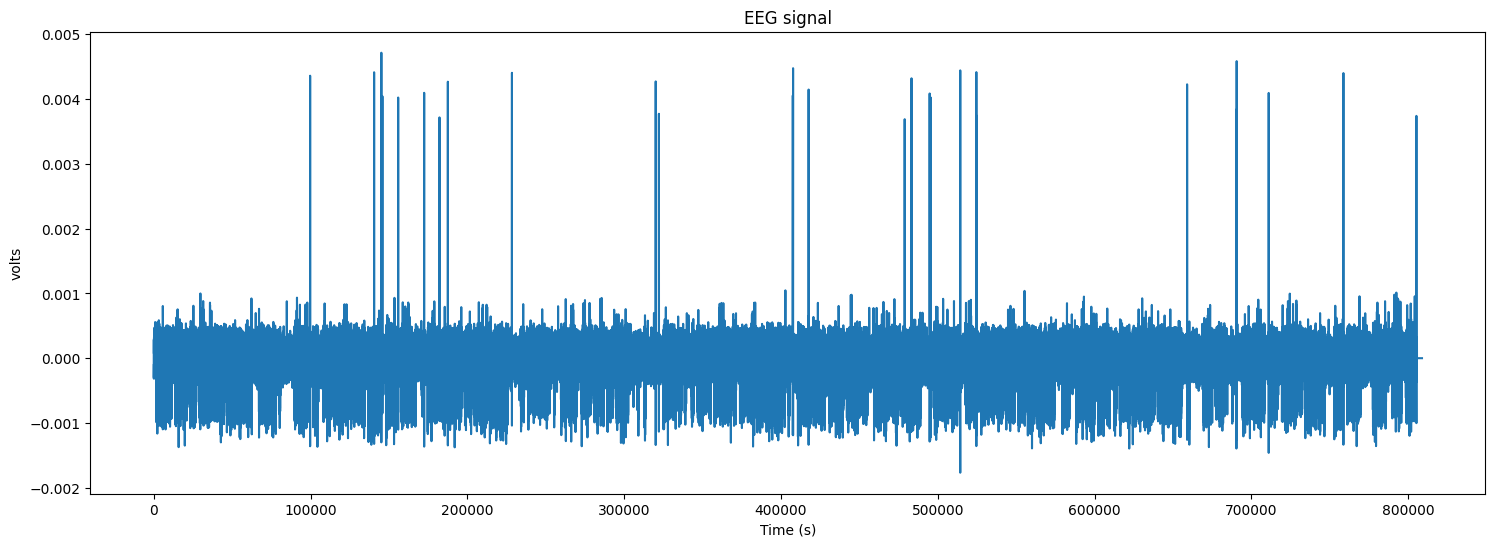

In [41]:
eeg_signal = nwbfile.acquisition["EEGSignal"]

# This recording spans roughly a week at the EEG sample rate, so loading and
# plotting `eeg_signal.data[:]` is hundreds of millions of points — too large
# for matplotlib (and too slow over remfile streaming). Subsample to ~50k
# points for the overview plot; users who want full-resolution data can slice
# `eeg_signal.data[start:stop]` directly.
n = eeg_signal.data.shape[0]
stride = max(1, n // 50_000)
ts_view = eeg_signal.starting_time + np.arange(0, n, stride) / eeg_signal.rate
data_view = eeg_signal.data[::stride]

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(ts_view, data_view)
ax.set_title(f"EEG signal (subsampled 1:{stride})")
ax.set_xlabel("Time (s)")
ax.set_ylabel(eeg_signal.unit)
plt.show()

## Experimental Sessions during the week

In [42]:
nwbfile.epochs.to_dataframe()

,start_time,stop_time,session_ids
id,,,
0,359058.744,359658.717,NeutralExposure
1,617599.999,617899.952,Recall1
2,529884.777,530158.743,FC
3,527067.677,527667.538,OfflineDay2Session1
4,528867.463,529467.359,OfflineDay2Session2
5,530667.282,531267.178,OfflineDay2Session3
6,532467.102,533066.997,OfflineDay2Session4
7,534266.922,534866.817,OfflineDay2Session5
8,536066.738,536666.632,OfflineDay2Session6


## Cell Registration across sessions

In [43]:
nwbfile.processing["cell_registration"]

,Ca_EEG2-1_FC,Ca_EEG2-1_NeutralExposure,Ca_EEG2-1_OfflineDay2Session10,Ca_EEG2-1_Recall1
id,,,,
0,0,2,3,-9999
1,1,4,4,-9999
2,-9999,-9999,5,-9999
3,3,-9999,-9999,-9999
,Ca_EEG2-1_FC,Ca_EEG2-1_NeutralExposure,Ca_EEG2-1_OfflineDay2Session11,Ca_EEG2-1_Recall1
id,,,,
0,0,2,-9999,-9999
1,-9999,4,3,-9999
2,2,-9999,-9999,-9999


In [45]:
nwbfile.processing["cell_registration"]["OfflineDay2Session10vsConditioningSessions"].to_dataframe()

,Ca_EEG2-1_FC,Ca_EEG2-1_NeutralExposure,Ca_EEG2-1_OfflineDay2Session10,Ca_EEG2-1_Recall1
id,,,,
0,0,2,3,-9999
1,1,4,4,-9999
2,-9999,-9999,5,-9999
3,3,-9999,-9999,-9999
4,-9999,-9999,7,-9999
...,...,...,...,...
1321,-9999,-9999,-9999,334
1322,-9999,-9999,-9999,20
1323,-9999,-9999,-9999,73
